#Telecom Customer Churn Analysis & Prediction


##Project Overview

This project analyzes customer churn using the IBM Telco Customer Churn dataset. It covers the complete data analytics and machine learning workflow, including data cleaning, feature engineering, exploratory data analysis (EDA), predictive modeling, and business recommendations. The objective is to identify the key factors influencing customer churn and develop a predictive model to help telecom companies improve customer retention.

#1.Import Libraries

In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#2.Load Dataset

In [130]:
df = pd.read_csv("/content/telecom-customer-churn-raw.csv")

print(df.shape)

(7043, 21)


#3.Data Understanding

##1.Dataset Shape

In [131]:
separator = '=' * 60
print(separator)
print('DATASET SHAPE')
print(separator)
print(df.shape)

DATASET SHAPE
(7043, 21)


##2.Columns

In [132]:
print(separator)
print('DATASET COLUMNS')
print(separator)
print(df.columns)

DATASET COLUMNS
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


##3.Overall Data Information

In [133]:
print(separator)
print('DATASET INFO')
print(separator)
print(df.info())

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-nu

##4.Random Samples

In [134]:
print(separator)
print('DATASET SAMPLE')
print(separator)
print(df.sample(5))

DATASET SAMPLE
      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
5005  2359-QWQUL  Female              0     Yes         No      39   
2059  7483-IQWIB    Male              0     Yes        Yes      37   
3255  4827-LTQRJ  Female              1     Yes        Yes      66   
1394  2272-JKMSI  Female              0     Yes        Yes      62   
5204  4282-ACRXS    Male              1     Yes         No      38   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
5005          Yes                No     Fiber optic            Yes  ...   
2059          Yes               Yes     Fiber optic             No  ...   
3255          Yes               Yes     Fiber optic            Yes  ...   
1394          Yes               Yes     Fiber optic             No  ...   
5204           No  No phone service             DSL             No  ...   

     DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
5005              Yes         Ye

##5.Duplicate Rows

In [135]:
print(separator)
print('DATASET DUPLICATED ROWS')
print(separator)
print(df.duplicated().sum())

DATASET DUPLICATED ROWS
0


##6.Missing Values



In [136]:
print(separator)
print('DATASET MISSING VALUES')
print(separator)
print(df.isnull().sum().sort_values(ascending=False))

DATASET MISSING VALUES
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


##7.Statistics

In [137]:
print(separator)
print('DATASET DESCRIPTIVE STATISTICS')
print(separator)
print(df.describe().round(2))

DATASET DESCRIPTIVE STATISTICS
       SeniorCitizen   tenure  MonthlyCharges
count        7043.00  7043.00         7043.00
mean            0.16    32.37           64.76
std             0.37    24.56           30.09
min             0.00     0.00           18.25
25%             0.00     9.00           35.50
50%             0.00    29.00           70.35
75%             0.00    55.00           89.85
max             1.00    72.00          118.75


#4.Data Cleaning

##1.Data type conversion

In [138]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print(df.info())
print(separator)
print(df.isnull().sum().sort_values(ascending=False))



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


##2.Handle Missing Values

In [139]:
df[df['TotalCharges'].isnull()]

df['TotalCharges'] = df['TotalCharges'].fillna(0)

print(df.info())
print(separator)
print(df.isnull().sum().sort_values(ascending=False))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


#5.Feature Engineering

##1.Tenure Group

In [140]:
condition = [
    (df['tenure'] <= 12),
    (df['tenure'] >= 13) & (df['tenure'] <= 24),
    (df['tenure'] >= 25) & (df['tenure'] <= 48),
    (df['tenure'] >= 49)

]

values = [
    'New Customer',
    'Regular Customer',
    'Loyal Customer',
    'Long-Term Customer']

df['tenure_category'] = np.select(
    condition,
    values,
    default='Unknowsn'
)


print(df['tenure_category'].value_counts())

tenure_category
Long-Term Customer    2239
New Customer          2186
Loyal Customer        1594
Regular Customer      1024
Name: count, dtype: int64


##2.Monthly Charges Category

In [141]:
condition = [
    (df['MonthlyCharges']) < 35,
    ((df['MonthlyCharges']) >= 35) & ((df['MonthlyCharges']) < 70),
    (df['MonthlyCharges']) >= 70
]

values = [
    'Low',
    'Medium',
    'High'
]

df['monthly_charge_category'] = np.select(condition, values, default = 'Unknowsn')


print(df['monthly_charge_category'].value_counts())

monthly_charge_category
High      3591
Low       1731
Medium    1721
Name: count, dtype: int64


##3.Total Charge Category

In [142]:
df['TotalCharges'].describe().round(2)

condition = [
    df['TotalCharges'] < 1000,
    ((df['TotalCharges']) >= 1000) & ((df['TotalCharges']) < 3500),
    ((df['TotalCharges']) >= 3500)
]

values = [
    'Low Spending',
    'Medium Spending',
    'High Spending'
]

df['total_charge_category'] = np.select(condition, values, default = 'Unknowsn')

print(df['total_charge_category'].value_counts())



total_charge_category
Low Spending       2904
Medium Spending    2229
High Spending      1910
Name: count, dtype: int64


##4.Family Status

In [143]:
df['family_status'] = np.where(
    (df['Partner'] == 'Yes') & (df['Dependents'] == 'Yes'),
    'Family',
    'Individual')

print(df['family_status'].value_counts())

family_status
Individual    5294
Family        1749
Name: count, dtype: int64


##5.Senior Citizen Label

In [144]:
df['Senior_citizen_label'] = df['SeniorCitizen'].map({
    0: 'No',
    1: 'Yes'
})

print(df['Senior_citizen_label'].value_counts())

Senior_citizen_label
No     5901
Yes    1142
Name: count, dtype: int64


#6.Exploratory Data Analysis

##1.customer Overview

### Business Question
**What is the overall customer churn distribution?**

In [145]:
print(separator)
print('CUSTOMER CHURN OVERVIEW')
print(separator)

print(df['Churn'].value_counts())

print(df['Churn'].value_counts(normalize=True).mul(100).round(2))

CUSTOMER CHURN OVERVIEW
Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


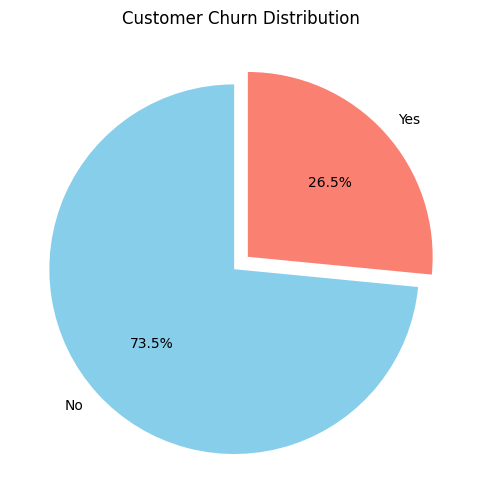

In [146]:
plt.figure(figsize=(6,6))

df['Churn'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    explode=(0.05, 0.05),
    colors=['skyblue', 'salmon']
)

plt.title('Customer Churn Distribution')
plt.ylabel('')
plt.show()

###Insight

Approximately three-quarters of customers remained with the company, while about one-quarter churned. Although customer retention is relatively strong, the churned segment is large enough to justify targeted retention strategies.

##2.Gender Analysis

### Business Question

**Does gender influence customer churn?**

In [147]:
print(separator)
print('GENDER CHURN OVERVIEW')
print(separator)
gender_churn = (
    df.groupby('gender')['Churn']
    .value_counts()
    .unstack()
)

print(gender_churn)

gender_churn_pct = (
    df.groupby('gender')['Churn']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .unstack()
)

print(gender_churn_pct)

GENDER CHURN OVERVIEW
Churn     No  Yes
gender           
Female  2549  939
Male    2625  930
Churn      No    Yes
gender              
Female  73.08  26.92
Male    73.84  26.16


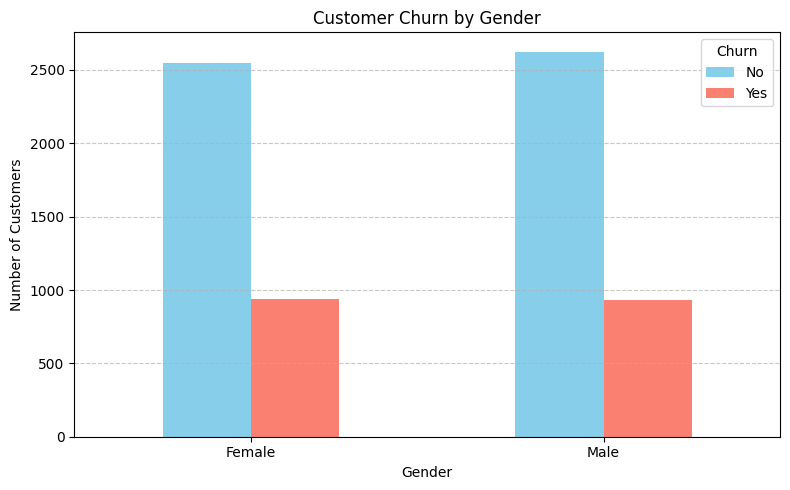

In [148]:
gender_churn.plot(
    kind='bar',
    figsize=(8,5),
    color=['skyblue', 'salmon']
)

plt.title('Customer Churn by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

###Insight

Male and female customers exhibit very similar churn patterns. Gender does not appear to be a significant factor influencing customer churn and is unlikely to be a strong predictor on its own.

##3.Senior Citizen Analysis

### Business Question

**Are senior citizens more likely to churn?**

In [149]:
print(separator)
print('SENIOR CITIZEN CHURN OVERVIEW')
print(separator)
senior_churn = (
    df.groupby('SeniorCitizen')['Churn']
    .value_counts()
    .unstack()
)

print(senior_churn)


senior_churn_pct = (
    df.groupby('SeniorCitizen')['Churn']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .unstack()
)

print(senior_churn_pct)

SENIOR CITIZEN CHURN OVERVIEW
Churn            No   Yes
SeniorCitizen            
0              4508  1393
1               666   476
Churn             No    Yes
SeniorCitizen              
0              76.39  23.61
1              58.32  41.68


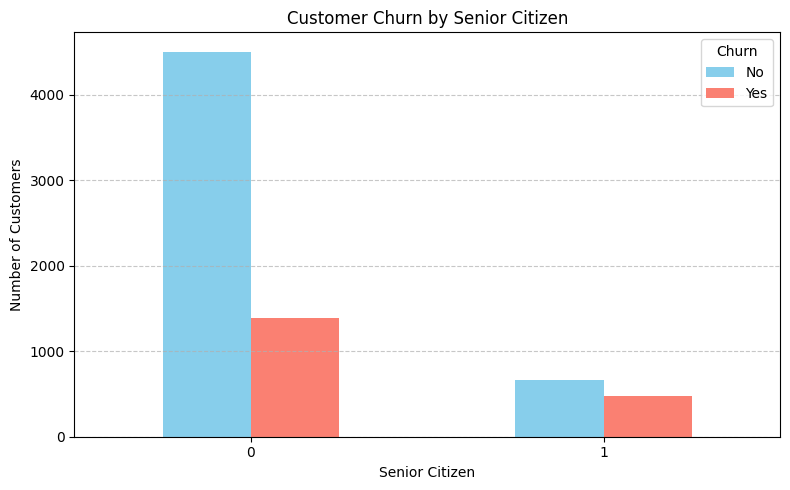

In [150]:
senior_churn.plot(
    kind='bar',
    figsize=(8,5),
    color=['skyblue', 'salmon']
)

plt.title('Customer Churn by Senior Citizen')
plt.xlabel('Senior Citizen')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

###Insight

Senior citizens show a noticeably higher churn rate compared to non-senior customers. This indicates that senior customers may require more personalized support, pricing plans, or retention programs.


##4.Family Status

### Business Question

**Does family status influence churn?**

In [151]:
print(separator)
print('FAMILY STATUS CHURN OVERVIEW')
print(separator)
family_status_churn = (
    df.groupby('family_status')['Churn']
    .value_counts()
    .unstack()
)

print(family_status_churn)

family_status_churn_pct = (
    df.groupby('family_status')['Churn']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .unstack()
)

print(family_status_churn_pct)


FAMILY STATUS CHURN OVERVIEW
Churn            No   Yes
family_status            
Family         1500   249
Individual     3674  1620
Churn             No    Yes
family_status              
Family         85.76  14.24
Individual     69.40  30.60


<Figure size 800x500 with 0 Axes>

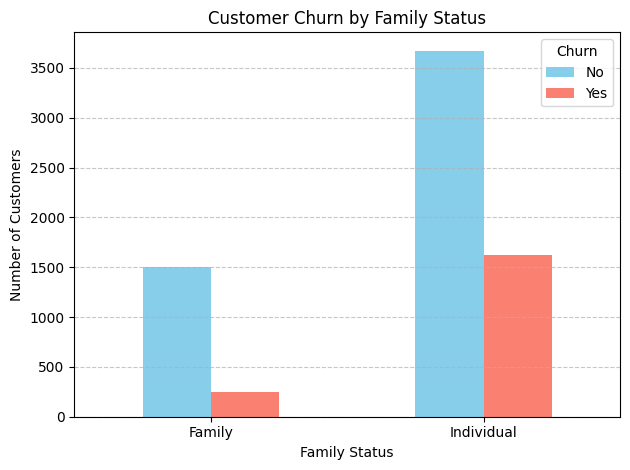

In [152]:
plt.figure(figsize=(8,5))

family_status_churn.plot(
    kind='bar',
    color=['skyblue', 'salmon']
)

plt.title('Customer Churn by Family Status')
plt.xlabel('Family Status')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

###Insight

Customers with partners and dependents tend to remain with the company longer, while individual customers exhibit relatively higher churn. Family-oriented customers may have stronger long-term service commitments.

##5.Contract Type

###Business Question

**Which cntract type experience the highest churn?**

In [153]:
print(separator)
print('CONTRACT TYPE CHURN OVERVIEW')
print(separator)
contract_churn = (
    df.groupby('Contract')['Churn']
    .value_counts()
    .unstack()
)

print(contract_churn)

contract_churn_pct = (
    df.groupby('Contract')['Churn']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .unstack()
)

print(contract_churn_pct)

CONTRACT TYPE CHURN OVERVIEW
Churn             No   Yes
Contract                  
Month-to-month  2220  1655
One year        1307   166
Two year        1647    48
Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.73  11.27
Two year        97.17   2.83


<Figure size 800x500 with 0 Axes>

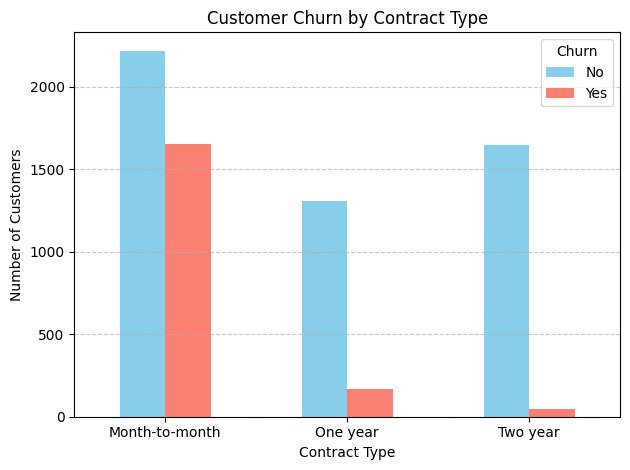

In [154]:
plt.figure(figsize=(8,5))

contract_churn.plot(
    kind='bar',
    color=['skyblue', 'salmon']
)

plt.title('Customer Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

###Insight

Customers with month-to-month contracts experience the highest churn, whereas one-year and two-year contract customers are significantly more likely to stay. Longer contract commitments appear to improve customer retention.

##6.Payment Method

###Business Question

**WHich payment method has the highest churn?**

In [155]:
print(separator)
print('PAYMENT METHOD CHURN OVERVIEW')
print(separator)
payment_method_churn = (
    df.groupby('PaymentMethod')['Churn']
    .value_counts()
    .unstack()
)

print(payment_method_churn)

payment_method_churn_pct = (
    df.groupby('PaymentMethod')['Churn']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .unstack()
)

print(payment_method_churn_pct)

PAYMENT METHOD CHURN OVERVIEW
Churn                        No   Yes
PaymentMethod                        
Bank transfer (automatic)  1286   258
Credit card (automatic)    1290   232
Electronic check           1294  1071
Mailed check               1304   308
Churn                         No    Yes
PaymentMethod                          
Bank transfer (automatic)  83.29  16.71
Credit card (automatic)    84.76  15.24
Electronic check           54.71  45.29
Mailed check               80.89  19.11


<Figure size 800x500 with 0 Axes>

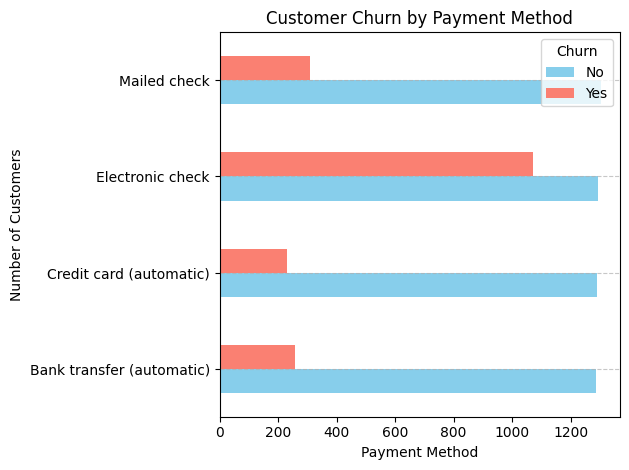

In [156]:
plt.figure(figsize=(8,5))

payment_method_churn.plot(
    kind='barh',
    color=['skyblue', 'salmon']
)

plt.title('Customer Churn by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

###Insight

Customers using Electronic Check display the highest churn rate among all payment methods. Encouraging customers to adopt automatic payment methods may help improve retention.

##7.Internet Service

###Business Question

**Does Internet service affect churn?**

In [157]:
print(separator)
print('INTERNET SERVICE CHURN OVERVIEW')
print(separator)
internet_service_churn = (
    df.groupby('InternetService')['Churn']
    .value_counts()
    .unstack()
)

print(internet_service_churn)

internet_service_churn_pct = (
    df.groupby('InternetService')['Churn']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .unstack()
)

print(internet_service_churn_pct)

INTERNET SERVICE CHURN OVERVIEW
Churn              No   Yes
InternetService            
DSL              1962   459
Fiber optic      1799  1297
No               1413   113
Churn               No    Yes
InternetService              
DSL              81.04  18.96
Fiber optic      58.11  41.89
No               92.60   7.40


<Figure size 800x500 with 0 Axes>

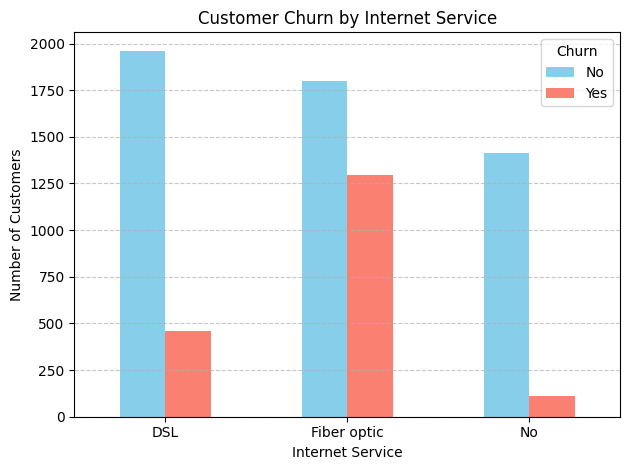

In [158]:
plt.figure(figsize=(8,5))

internet_service_churn.plot(
    kind='bar',
    color=['skyblue', 'salmon']
)

plt.title('Customer Churn by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

###Insight

Customers using Fiber Optic internet exhibit higher churn compared to DSL users. This suggests opportunities to investigate service quality, pricing, or customer satisfaction for Fiber Optic customers.

##8.Tenure Group

###Business Question

**Do long-term customers churn less?**

In [159]:
print(separator)
print('TENURE GROUP CHURN OVERVIEW')
print(separator)
tenure_group_churn = (
    df.groupby('tenure_category')['Churn']
    .value_counts()
    .unstack()
)

print(tenure_group_churn)

tenure_group_churn_pct = (
    df.groupby('tenure_category')['Churn']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .unstack()
)

print(tenure_group_churn_pct)

TENURE GROUP CHURN OVERVIEW
Churn                 No   Yes
tenure_category               
Long-Term Customer  2026   213
Loyal Customer      1269   325
New Customer        1149  1037
Regular Customer     730   294
Churn                  No    Yes
tenure_category                 
Long-Term Customer  90.49   9.51
Loyal Customer      79.61  20.39
New Customer        52.56  47.44
Regular Customer    71.29  28.71


<Figure size 800x500 with 0 Axes>

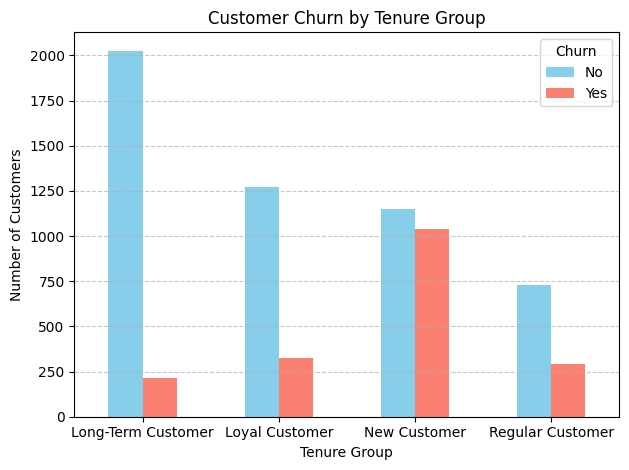

In [160]:
plt.figure(figsize=(8,5))

tenure_group_churn.plot(
    kind='bar',
    color=['skyblue', 'salmon']
)

plt.title('Customer Churn by Tenure Group')
plt.xlabel('Tenure Group')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

###Insight

Customer churn decreases as tenure increases. Newly acquired customers are considerably more likely to churn, while long-term customers demonstrate much higher loyalty.

##9.Monthly Charge Category

###Business Question

**Are cutomers with higher monthly charges more likely to churn?**

In [161]:
print(separator)
print('MONTHLY CHARGE CATEGORY CHURN OVERVIEW')
print(separator)
monthly_charge_category_churn = (
    df.groupby('monthly_charge_category')['Churn']
    .value_counts()
    .unstack()
)

print(monthly_charge_category_churn)

monthly_charge_category_churn_pct = (
    df.groupby('monthly_charge_category')['Churn']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .unstack()
)

print(monthly_charge_category_churn_pct)

MONTHLY CHARGE CATEGORY CHURN OVERVIEW
Churn                      No   Yes
monthly_charge_category            
High                     2317  1274
Low                      1543   188
Medium                   1314   407
Churn                       No    Yes
monthly_charge_category              
High                     64.52  35.48
Low                      89.14  10.86
Medium                   76.35  23.65


<Figure size 800x500 with 0 Axes>

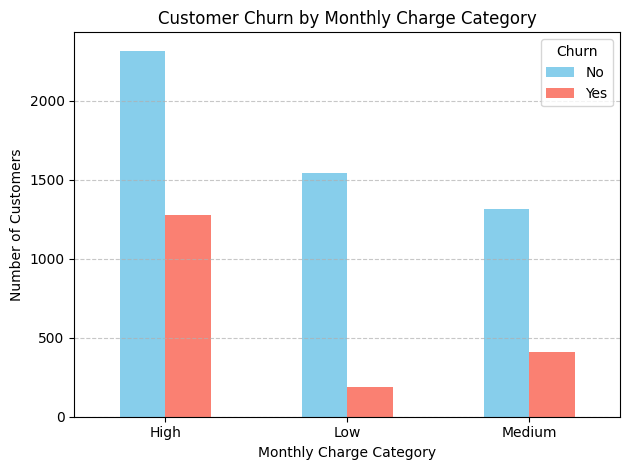

In [162]:
plt.figure(figsize=(8,5))
monthly_charge_category_churn.plot(
    kind='bar',
    color=['skyblue', 'salmon']
)
plt.title('Customer Churn by Monthly Charge Category')
plt.xlabel('Monthly Charge Category')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

###Insight

Customers with higher monthly charges tend to churn more frequently than those with lower monthly charges. Pricing strategies and value-added services may influence customer retention.

##10.Total Charge Category

###Business Question

**Does total custeomer spending relate to churn?**

In [163]:
print(separator)
print('TOTAL CHARGE CATEGORY CHURN OVERVIEW')
print(separator)
total_charge_category_churn = (
    df.groupby('total_charge_category')['Churn']
    .value_counts()
    .unstack()
)

print(total_charge_category_churn)

total_charge_category_churn_pct = (
    df.groupby('total_charge_category')['Churn']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .unstack()
)

print(total_charge_category_churn_pct)

TOTAL CHARGE CATEGORY CHURN OVERVIEW
Churn                    No   Yes
total_charge_category            
High Spending          1628   282
Low Spending           1834  1070
Medium Spending        1712   517
Churn                     No    Yes
total_charge_category              
High Spending          85.24  14.76
Low Spending           63.15  36.85
Medium Spending        76.81  23.19


<Figure size 800x500 with 0 Axes>

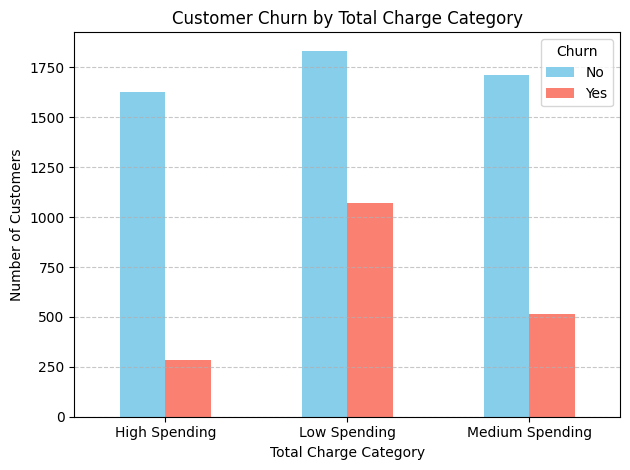

In [164]:
plt.figure(figsize=(8,5))
total_charge_category_churn.plot(
    kind='bar',
    color=['skyblue', 'salmon']
)
plt.title('Customer Churn by Total Charge Category')
plt.xlabel('Total Charge Category')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

###Insight

Customers with higher accumulated total charges generally have lower churn rates, indicating that long-term customers contribute more revenue and are more likely to remain with the company.

##11.Correlation Matrix

In [165]:
correlation_matrix = df.corr(numeric_only=True)

print(correlation_matrix)

                SeniorCitizen    tenure  MonthlyCharges  TotalCharges
SeniorCitizen        1.000000  0.016567        0.220173      0.103006
tenure               0.016567  1.000000        0.247900      0.826178
MonthlyCharges       0.220173  0.247900        1.000000      0.651174
TotalCharges         0.103006  0.826178        0.651174      1.000000


###Insight

Most numerical variables exhibit weak to moderate correlations, suggesting limited multicollinearity. Tenure and Total Charges show a stronger positive relationship, as customers with longer tenure naturally accumulate higher charges.

##12.Monthly Charges vs Total Charges (Scatter Plot)

<Figure size 800x500 with 0 Axes>

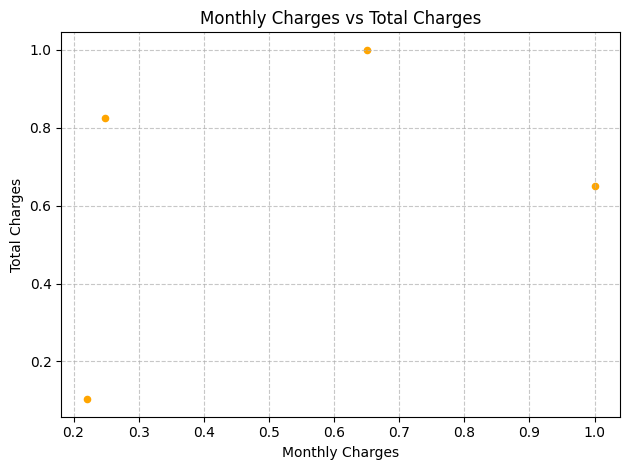

In [166]:
plt.figure(figsize=(8,5))
correlation_matrix.plot(
    kind='scatter',
    x='MonthlyCharges',
    y='TotalCharges',
    color='orange'

)
plt.title('Monthly Charges vs Total Charges')
plt.xlabel('Monthly Charges')
plt.ylabel('Total Charges')
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



###Insight

Total Charges increase with Monthly Charges and customer tenure. Long-standing customers accumulate significantly higher total revenue over time, highlighting their importance to the business.

##13.Monthly Charges by Churn (Boxplot)

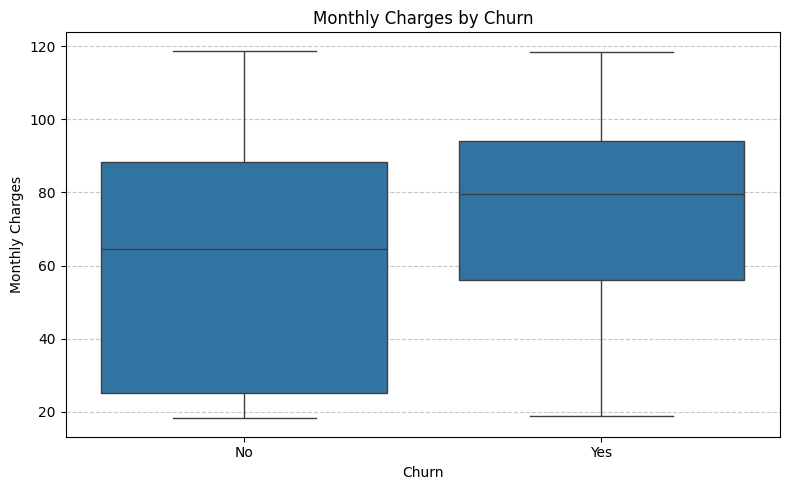

In [167]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x='Churn',
    y='MonthlyCharges'
)
plt.title('Monthly Charges by Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

###Insight

Customers who churn generally have higher monthly charges than customers who remain. This indicates that pricing may influence customer decisions, particularly for higher-cost service plans.

##14.Tenure Distribution (Histogram)

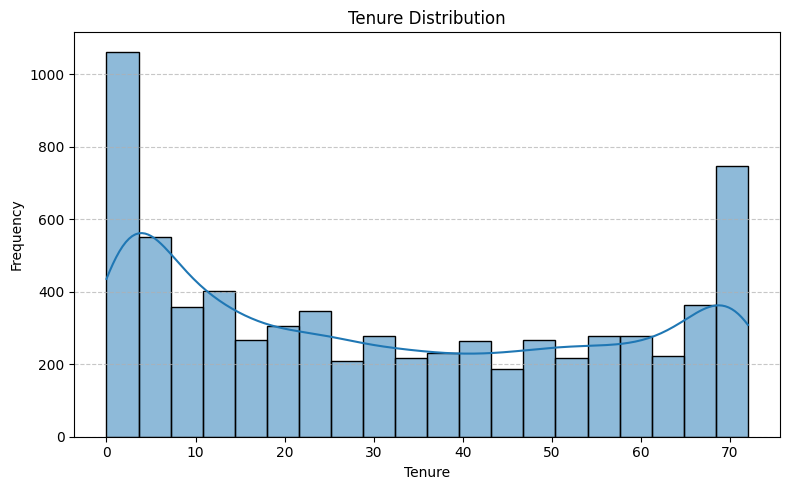

In [168]:
plt.figure(figsize=(8,5))
sns.histplot(
    data=df,
    x='tenure',
    bins=20,
    kde=True
)
plt.title('Tenure Distribution')
plt.xlabel('Tenure')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

###Insight

The customer base includes a large number of recently acquired customers as well as many long-term subscribers. This mixed distribution suggests ongoing customer acquisition alongside a stable loyal customer segment.

##15.Business Insights

1.Month-to-month contract customers have the highest likelihood of churn.

2.Customer churn decreases significantly as tenure increases.

3.Fiber Optic internet customers exhibit relatively higher churn rates.

4.Higher monthly charges are associated with increased customer churn.

5.Senior citizens churn more frequently than non-senior customers.

6.Electronic Check users have the highest churn among payment methods.

7.Gender has minimal influence on customer churn.

8.Customers with partners and dependents demonstrate better retention.

9.Long-term customers contribute higher lifetime value through greater Total Charges.

10.The analysis identifies contract type, tenure, internet service, and monthly charges as the strongest business factors associated with churn.

# Export Cleaned Dataset

The cleaned dataset is exported for use in the dashboard and machine learning pipeline.

In [169]:
df.to_csv("telecom-customer-churn-cleaned.csv", index=False)

#7.Machine Learning

##1.Import dataset

In [170]:
df = pd.read_csv("/content/telecom-customer-churn-cleaned.csv")

print(df.shape)

print(df.dtypes)

(7043, 26)
customerID                  object
gender                      object
SeniorCitizen                int64
Partner                     object
Dependents                  object
tenure                       int64
PhoneService                object
MultipleLines               object
InternetService             object
OnlineSecurity              object
OnlineBackup                object
DeviceProtection            object
TechSupport                 object
StreamingTV                 object
StreamingMovies             object
Contract                    object
PaperlessBilling            object
PaymentMethod               object
MonthlyCharges             float64
TotalCharges               float64
Churn                       object
tenure_category             object
monthly_charge_category     object
total_charge_category       object
family_status               object
Senior_citizen_label        object
dtype: object


##2.Import ML Libraries

In [171]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    ConfusionMatrixDisplay
)

##3.Encode Categorical Columns

In [172]:
categorical_columns = df.select_dtypes(include='object').columns

print(categorical_columns)
print(categorical_columns.shape)

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn',
       'tenure_category', 'monthly_charge_category', 'total_charge_category',
       'family_status', 'Senior_citizen_label'],
      dtype='object')
(22,)


##4.Data Encoding

###4.1 Create a Dummy Dataset

In [173]:
ml_df = df.copy().drop(columns='Senior_citizen_label')

print(ml_df.shape)

print(ml_df.dtypes)

(7043, 25)
customerID                  object
gender                      object
SeniorCitizen                int64
Partner                     object
Dependents                  object
tenure                       int64
PhoneService                object
MultipleLines               object
InternetService             object
OnlineSecurity              object
OnlineBackup                object
DeviceProtection            object
TechSupport                 object
StreamingTV                 object
StreamingMovies             object
Contract                    object
PaperlessBilling            object
PaymentMethod               object
MonthlyCharges             float64
TotalCharges               float64
Churn                       object
tenure_category             object
monthly_charge_category     object
total_charge_category       object
family_status               object
dtype: object


###4.2 Encode target variable

In [174]:
label_encoder = LabelEncoder()

ml_df['Churn'] = label_encoder.fit_transform(ml_df['Churn'])

print(ml_df['Churn'].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


###4.3 Drop Unnecessary Columns

In [175]:
ml_df = ml_df.drop(columns='customerID')

In [176]:
categorical_cols = ml_df.select_dtypes(include='object').columns

print(categorical_cols)
print(categorical_cols.shape)

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'tenure_category',
       'monthly_charge_category', 'total_charge_category', 'family_status'],
      dtype='object')
(19,)


###4.4 One-Hot Encode feature columns

In [177]:
ml_df = pd.get_dummies(
    ml_df,
    columns=ml_df.select_dtypes(include='object').columns,
    drop_first=True,
    dtype=int
)

print(ml_df.shape)

(7043, 39)


##5.Feature & Target Selection

In [178]:
X = ml_df.drop('Churn', axis=1)

y = ml_df['Churn']

print("Feutures Shape : ", X.shape)
print("Target Shape : ", y.shape)

print(y.value_counts())

Feutures Shape :  (7043, 38)
Target Shape :  (7043,)
Churn
0    5174
1    1869
Name: count, dtype: int64


##6.Train-Test Split

In [179]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Features :", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Target :", y_train.shape)
print("Testing Target :", y_test.shape)


Training Features : (5634, 38)
Testing Features : (1409, 38)
Training Target : (5634,)
Testing Target : (1409,)


##7.Feature Scaling

In [180]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print(ml_df.shape)
print(X.shape)
print(X_train.shape)
print(X_test.shape)

(7043, 39)
(7043, 38)
(5634, 38)
(1409, 38)


# Model Result Storing List

In [48]:
model_results = []

##8.Logistic Regression Model

###8.1 Train Logistic Regression Model

In [49]:
log_reg = LogisticRegression(random_state=42)

log_reg.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

###8.2 Predictions

In [50]:
y_pred_lr = log_reg.predict(X_test_scaled)

print(y_pred_lr)

[0 1 0 ... 0 0 0]


###8.3 Model Evaluation

In [51]:
print(separator)
print('LOGISTIC REGRESSION MODEL EVALUATION')
print(separator)

print(f"Accuracy : {accuracy_score(y_test, y_pred_lr):.2f}")
print(f"Precision : {precision_score(y_test, y_pred_lr):.2f}")
print(f"Recall : {recall_score(y_test, y_pred_lr):.2f}")
print(f"F1 Score : {f1_score(y_test, y_pred_lr):.2f}")
print(f"ROC AUC Score : {roc_auc_score(y_test, y_pred_lr):.2f}")

LOGISTIC REGRESSION MODEL EVALUATION
Accuracy : 0.80
Precision : 0.65
Recall : 0.52
F1 Score : 0.58
ROC AUC Score : 0.71


In [52]:
model_results.append({
     "Model" : "Logistic Regression",
     "Accuracy" : accuracy_score(y_test, y_pred_lr),
     "Precision" : precision_score(y_test, y_pred_lr),
     "Recall" : recall_score(y_test, y_pred_lr),
     "F1 Score" : f1_score(y_test, y_pred_lr),
     "ROC AUC Score" : roc_auc_score(y_test, y_pred_lr)
})

###8.4 Classification Report

In [53]:
print(separator)
print('LOGISTIC REGRESSION MODEL CLASSIFICATION REPORT')
print(separator)
print(classification_report(y_test, y_pred_lr))

LOGISTIC REGRESSION MODEL CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



###8.5 Confusion Matrix

LOGISTIC REGRESSION MODEL CONFUSION MATRIX
[[930 105]
 [179 195]]


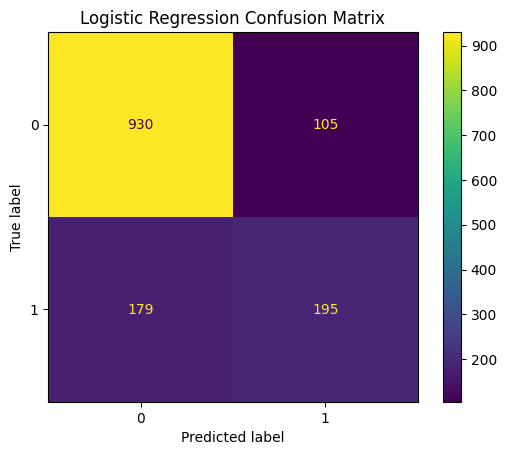

In [54]:
print(separator)
print('LOGISTIC REGRESSION MODEL CONFUSION MATRIX')
print(separator)
print(confusion_matrix(y_test, y_pred_lr))
print(separator)


ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr)
plt.title('Logistic Regression Confusion Matrix')
plt.show()

##9.Decision Tree Classifier Model

###9.1 Train Decision Tree model

In [55]:
dec_tree = DecisionTreeClassifier(random_state=42)

dec_tree.fit(X_train_scaled, y_train)

DecisionTreeClassifier(random_state=42)

###9.2 Predictions

In [56]:
y_pred_dt = dec_tree.predict(X_test_scaled)

print(y_pred_dt)

[0 1 0 ... 0 0 0]


###9.3 Model Evaluation

In [57]:
print(separator)
print('DECISION TREE MODEL EVALUATION')
print(separator)

print(f"Accuracy : {accuracy_score(y_test, y_pred_dt):.2f}")
print(f"Precision : {precision_score(y_test, y_pred_dt):.2f}")
print(f"Recall : {recall_score(y_test, y_pred_dt):.2f}")
print(f"F1 Score : {f1_score(y_test, y_pred_dt):.2f}")
print(f"ROC AUC Score : {roc_auc_score(y_test, y_pred_dt):.2f}")

DECISION TREE MODEL EVALUATION
Accuracy : 0.73
Precision : 0.49
Recall : 0.48
F1 Score : 0.48
ROC AUC Score : 0.65


In [58]:
model_results.append({
     "Model" : "Decision Tree Classifier",
     "Accuracy" : accuracy_score(y_test, y_pred_dt),
     "Precision" : precision_score(y_test, y_pred_dt),
     "Recall" : recall_score(y_test, y_pred_dt),
     "F1 Score" : f1_score(y_test, y_pred_dt),
     "ROC AUC Score" : roc_auc_score(y_test, y_pred_dt)
})

###9.4 Classification Report

In [59]:
print(separator)
print('DECISION TREE MODEL CLASSIFICATION REPORT')
print(separator)
print(classification_report(y_test, y_pred_dt))

DECISION TREE MODEL CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.81      0.82      0.82      1035
           1       0.49      0.48      0.48       374

    accuracy                           0.73      1409
   macro avg       0.65      0.65      0.65      1409
weighted avg       0.73      0.73      0.73      1409



###9.5 Confusion Matrix

DECISION TREE MODEL CONFUSION MATRIX
[[852 183]
 [196 178]]


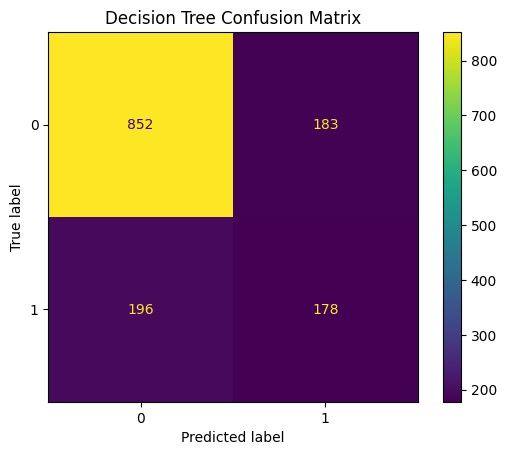

In [60]:
print(separator)
print('DECISION TREE MODEL CONFUSION MATRIX')
print(separator)
print(confusion_matrix(y_test, y_pred_dt))
print(separator)


ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt)
plt.title('Decision Tree Confusion Matrix')
plt.show()

##10.Random Forest Classifier Model

###10.1 Train Random Forest Model

In [61]:
ran_for = RandomForestClassifier(random_state=42)

ran_for.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

###10.2 Predictions

In [62]:
y_pred_rf = ran_for.predict(X_test_scaled)

print(y_pred_rf)

[0 1 0 ... 0 0 0]


###10.3 Model Evaluation

In [63]:
print(separator)
print('RANDOM FOREST MODEL EVALUATION')
print(separator)
print(f"Accuracy : {accuracy_score(y_test, y_pred_rf):.2f}")
print(f"Precision : {precision_score(y_test, y_pred_rf):.2f}")
print(f"Recall : {recall_score(y_test, y_pred_rf):.2f}")
print(f"F1 Score : {f1_score(y_test, y_pred_rf):.2f}")
print(f"ROC AUC Score : {roc_auc_score(y_test, y_pred_rf):.2f}")


RANDOM FOREST MODEL EVALUATION
Accuracy : 0.79
Precision : 0.63
Recall : 0.51
F1 Score : 0.56
ROC AUC Score : 0.70


In [64]:
model_results.append({
    "Model" : "Random Forest Classifier",
    "Accuracy" : accuracy_score(y_test, y_pred_rf),
    "Precision" : precision_score(y_test, y_pred_rf),
    "Recall" : recall_score(y_test, y_pred_rf),
    "F1 Score" : f1_score(y_test, y_pred_rf),
    "ROC AUC Score" : roc_auc_score(y_test, y_pred_rf)
})

###10.4 Classification Report

In [65]:
print(separator)
print('RANDOM FOREST MODEL CLASSIFICATION REPORT')
print(separator)
print(classification_report(y_test, y_pred_rf))

RANDOM FOREST MODEL CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.63      0.51      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



###10.5 Confusion Matrix

RANDOM FOREST MODEL CONFUSION MATRIX
[[922 113]
 [183 191]]


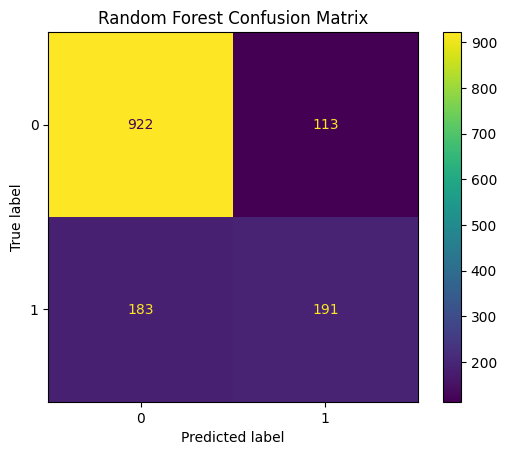

In [66]:
print(separator)
print('RANDOM FOREST MODEL CONFUSION MATRIX')
print(separator)
print(confusion_matrix(y_test, y_pred_rf))
print(separator)


ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.title('Random Forest Confusion Matrix')
plt.show()

##11.Create Comparison Table

In [67]:
comparison_df = pd.DataFrame(model_results)

comparison_df = comparison_df.round(2)

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC Score
0,Logistic Regression,0.80,0.65,0.52,0.58,0.71
1,Decision Tree Classifier,0.73,0.49,0.48,0.48,0.65
2,Random Forest Classifier,0.79,0.63,0.51,0.56,0.70


###Best Performing Model

In [68]:
best_model = comparison_df.loc[
    comparison_df["Accuracy"].idxmax()
]

print(separator)
print("BEST PERFORMING MODEL")
print(separator)

print(best_model)

BEST PERFORMING MODEL
Model            Logistic Regression
Accuracy                         0.8
Precision                       0.65
Recall                          0.52
F1 Score                        0.58
ROC AUC Score                   0.71
Name: 0, dtype: object


###Insight

Although Decision Tree and Random Forest were evaluated, Logistic Regression achieved the best balance across accuracy, precision, recall, F1-score, and ROC-AUC. Therefore, it was selected as the final model.

##12.Feature Coefficients (Logistic Regression)

In [182]:
feature_importance = pd.DataFrame({
    "Feature" : X.columns,
    "Importance" : abs(log_reg.coef_[0])
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(10).round(2))

                             Feature  Importance
1                             tenure        1.17
2                     MonthlyCharges        0.81
10       InternetService_Fiber optic        0.80
25                 Contract_Two year        0.63
24                 Contract_One year        0.29
32  tenure_category_Regular Customer        0.29
21                   StreamingTV_Yes        0.26
23               StreamingMovies_Yes        0.26
30    tenure_category_Loyal Customer        0.24
9                  MultipleLines_Yes        0.24


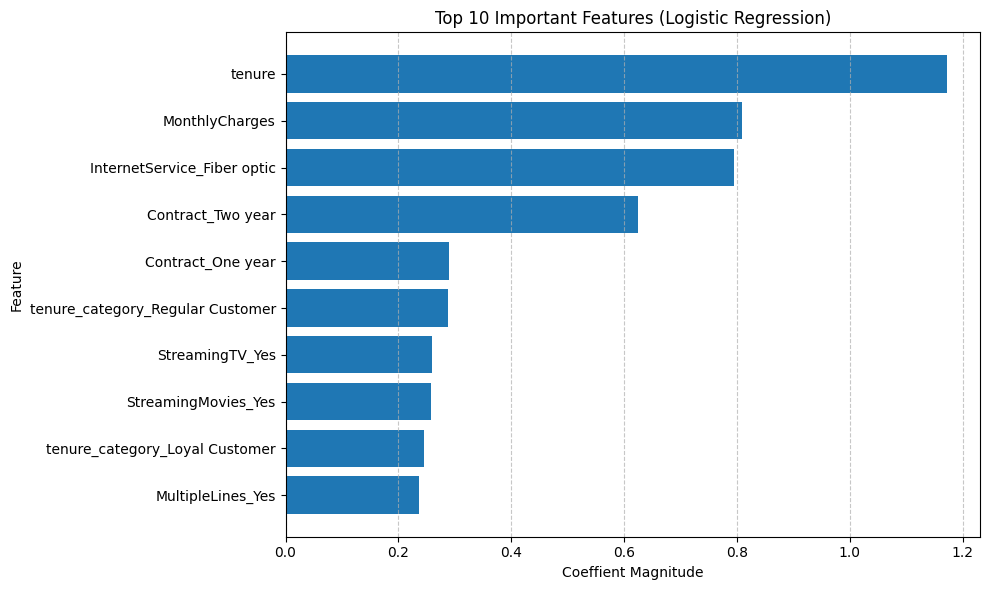

In [183]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.title("Top 10 Important Features (Logistic Regression)")
plt.xlabel("Coeffient Magnitude")
plt.ylabel("Feature")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

##13.Business Recommendations

1.Encourage customers to switch from month-to-month to annual contracts.

2.Identify new customers within their first year for proactive retention.

3.Review pricing for customers with high monthly charges.

4.Improve service quality for Fiber Optic customers.

5.Promote automatic payment methods instead of Electronic Check.

6.Use the prediction model to identify high-risk customers and launch targeted retention campaigns.

##14.Conclusion

This project analyzed customer churn using data cleaning, feature engineering, exploratory data analysis, and machine learning techniques.

Logistic Regression achieved the best predictive performance with an accuracy of approximately 80%.

Key churn drivers include contract type, tenure, monthly charges, and internet service.

The developed model can help businesses identify high-risk customers and support proactive retention strategies.

##15.Export Dataset

In [181]:
ml_df.to_csv("telecom-customer-churn-model-data.csv", index=False)